# Regression analysis (Energy and position)

## First run - sc4422

### Parameters
wcte_regression.yaml

Overrides: 

data.dataset.transforms=['double_cover'] model.conv_pad_mode='circular' \
tasks.train.data_loaders.train.batch_size=1024 \
tasks.evaluate.data_loaders.test.batch_size=2048 \
tasks.train.data_loaders.validation.batch_size=2048 \
tasks.train.data_loaders.train.pre_transforms=[]


### Data/ Paths
data.split_path='/vols/hyperk/WCTE/ML_2025/cds_geometry/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz' \
data.dataset.geometry_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/geometries/WCTE_geometry_v1.12.21.npz' \
data.dataset.mpmt_positions_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/mpmt_pos_files/WCTE_mpmt_position_correct_251125.npz' \
data.dataset.h5file='/vols/hyperk/WCTE/ML_2025/cds_geometry/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5'

### Disclaimer
New data (fixed FC and fixed mu) had 2 extra events than fitqun, causing some errors when separating out fitqun events to compare with the test outputs of the ML model. This was fixed using a different function / handling of the fitqun events (the missing indices section - using the event labels of h5 for the true labels of fitqun) -- old code assumed that h5 files were a subset of fitqun. The two events would have been removed in the physics cuts later on anyway, so should be fine, but should double check in case of any misalignment.

Direction still running but is on hold.

### Outputs
Run directory: /vols/hyperk/users/sc4422/first_run/outputs/regression/$DATE

### WatChMaL github version
workshop_2025-91-g158c799

# Setup

In [ ]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/vols/hyperk/users/sc4422/first_run/WatChMaL')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression import (WatChMaLPositionRegression, WatChMaLDirectionRegression, WatChMaLEnergyRegression, CombinedRegressionRun,
                                 FitQun1ParticleFit, plot_histograms, plot_resolution_profile, plot_bias_profile, tabulate_statistics)
from analysis.read import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-91-g158c799


# Processing h5 data

In [7]:
cds_geo_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry'

In [8]:
# idxs_path_new_geo = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz"
# test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']

idxs_path_new_geo = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/emu_ALL.npz"
test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']

In [9]:
# data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5"
# h5_file_new_geo = h5py.File(data_path_new_geo, "r")

data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu.h5"
h5_file_new_geo = h5py.File(data_path_new_geo, "r")

In [10]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    # h5_charge     = np.array(h5file['hit_charge']).squeeze()
    # charge        = h5_charge[hitsindex[testidxs+1] - h5_charge[hitsindex[testidxs]]]
    # h5_times       = np.array(h5file['hit_time']).squeeze()
    # times         = h5_times[hitsindex[testidxs+1] - h5_times[hitsindex[testidxs]]]
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum,
        # 'charge': charge,
        # 'times': times
    }

In [11]:
data_new_geo = get_values(h5_file_new_geo, test_idxs_new_geo)

# Processing fitQun data

In [12]:
def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
    N = len(all_event_ids)
    cut_start_idxs: list[int] = [0]
    CUTOFF = 500
    for i in range(N - 1):
        if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
            cut_start_idxs.append(i+ 1)
    cut_start_idxs.append(len(all_event_ids)-1)
    return cut_start_idxs

def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
    missing_ids_fq = []
    missing_inds_fq = []
    missing_ids_h5 = []    
    missing_inds_h5 = []
    n_cuts = len(fq_cuts)
    assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
    for i in range(1, n_cuts):
        fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
        h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

        fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
        h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

        assert fq_ids[0] < 100
        assert fq_ids[-1] > 990

        missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
        if len(missing_both) > 0:
            print(missing_both)

        missing_fq = np.setdiff1d(fq_ids, h5_ids)
        inds_fq = np.searchsorted(fq_ids, missing_fq)

        missing_ids_fq.append(missing_fq.tolist())
        missing_inds_fq.append(fq_start_idx + inds_fq)


        missing_h5 = np.setdiff1d(h5_ids, fq_ids)
        inds_h5 = np.searchsorted(h5_ids, missing_h5)

        missing_ids_h5.append(missing_h5.tolist())
        missing_inds_h5.append(h5_start_idx + inds_h5)
    
    return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [13]:
# fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
# fq = FiTQunOutput(fitqun_files_full)

In [14]:
# #Checking difference between fitqun and h5 file event id and missing_indices to see if they are the same shape
# fq_event_ids = fq.chain['nevt'] #.compute()
# fq_event_ids =  ak.to_numpy(fq_event_ids) -1
# h5_event_ids = data_new_geo['event_ids']

# fq_cuts = get_cut_start_idxs(fq_event_ids)
# h5_cuts = get_cut_start_idxs(h5_event_ids)
# missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

# print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
# print('The number of extra fq indices is:', len(missing_indices_fq))
# print('The number of extra h5 indices is:', len(missing_indices_h5))

In [15]:
# fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
# h5_keep_idx = np.delete(np.arange(len(data_new_geo['event_ids'])), missing_indices_h5)

# fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==2]
# fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==1]
# fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [16]:
# h5_electron_flag = fq.electron_flag
# h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)
# h5_muon_flag = fq.muon_flag#.compute()
# h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

# fc_cut = data_new_geo['fc'][h5_keep_idx]
# mu_cut = data_new_geo['labels'][h5_keep_idx]==2
# el_cut = data_new_geo['labels'][h5_keep_idx]==1

# reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

In [17]:
# mu_mu = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]
# el_mu = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]

# mu_el = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# el_el = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# fq_mu_nll = mu_mu - el_mu
# fq_el_nll = mu_el - el_el

# Making cuts and extracting data

In [18]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [19]:
def apply_cuts(data):
    fc_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = data['towall'] > 100
    nhits_cut = data['nhits'] > 25
    energies_cut = data['energies'] > 800

    # select the true electron and muon events that pass the cuts
    cuts = ( fc_cut
            & nhits_cut
            & towall_cut
            )
    return cuts

cuts_new_geo = apply_cuts(data_new_geo)

In [20]:
e_idxs_new_geo = data_new_geo['labels']==1
mu_idxs_new_geo = data_new_geo['labels']==2

In [21]:
def get_particle_quantities(data, particle_type, cuts=None):
    """
    Extracts quantities for a given particle type from the data dictionary and
    returns a tuple in the order expected by the notebook unpacking.

    Returns: (labels, momentum, positions, directions, angles,
              dwall, towall, cuts_selected, indices)
    """
    particle_mask = data['labels'] == particle_type

    labels = data['labels'][particle_mask]
    momentum = data['momentum'][particle_mask]
    positions = data['positions'][particle_mask]
    directions = data['directions'][particle_mask]
    angles = data['angles'][particle_mask]
    dwall = data['dwall'][particle_mask]
    towall = data['towall'][particle_mask]
    cuts_selected = cuts[particle_mask] if cuts is not None else None
    indices = cuts[particle_mask]

    return (labels, momentum, positions, directions, angles,
            dwall, towall, cuts_selected, indices)

In [22]:
e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo, 1, cuts_new_geo)
mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo, 2, cuts_new_geo)

# should replace this with the method below / other way around

In [23]:
resnet_args = {'linestyle':"-"}
electron_args_new_geo = {'indices':test_idxs_new_geo[e_idxs_new_geo], 'selection':e_cuts}
muon_args_new_geo = {'indices':test_idxs_new_geo[mu_idxs_new_geo],'selection':mu_cuts}

# Loading ResNet results

In [24]:
outdir_reg = "/vols/hyperk/users/sc4422/first_run/outputs/regression/"

In [25]:
# output_energy = "2026-02-05/18-30-30"
# output_pos = "2026-02-05/21-17-54"
# output_dir = "2026-02-11/13-14-33/"


#output_dir = "2026-02-11/13-14-33"
output_dir = 'electrons/directions/2026-02-22/20-30-42' # the together ones are accidentally in electrons, check config
output_pos = 'electrons/position/2026-02-23/16-47-19'
output_energy = 'electrons/energy/2026-02-27/00-23-49'

resnet_muon_position = [
    WatChMaLPositionRegression(outdir_reg+output_pos, "ResNet 50 Position", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)
]
resnet_muon_direction = [
    WatChMaLDirectionRegression(outdir_reg+output_dir, "ResNet50 Direction", mu_dir, **muon_args_new_geo, **resnet_args)
]
resnet_muon_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_energy, "ResNet50 Energy ", mu_mom, 2, **muon_args_new_geo, **resnet_args)
]


resnet_e_position = [
    WatChMaLPositionRegression(outdir_reg+output_pos, "ResNet 50 Position", e_pos, e_dir, **electron_args_new_geo, **resnet_args)
]
resnet_e_direction = [
    WatChMaLDirectionRegression(outdir_reg+output_dir, "ResNet50 Direction", e_dir, **electron_args_new_geo, **resnet_args)
]
resnet_e_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_energy, "ResNet50 Energy ", e_mom, 1, **electron_args_new_geo, **resnet_args)
]



/vols/hyperk/users/sc4422/first_run/WatChMaL/watchmal/utils/math.py:95: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(energy**2 - mass**2)


# Plot training progression

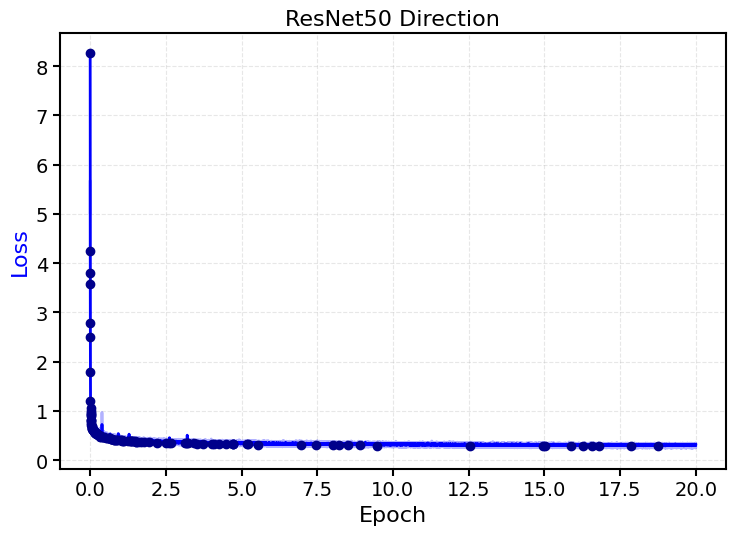

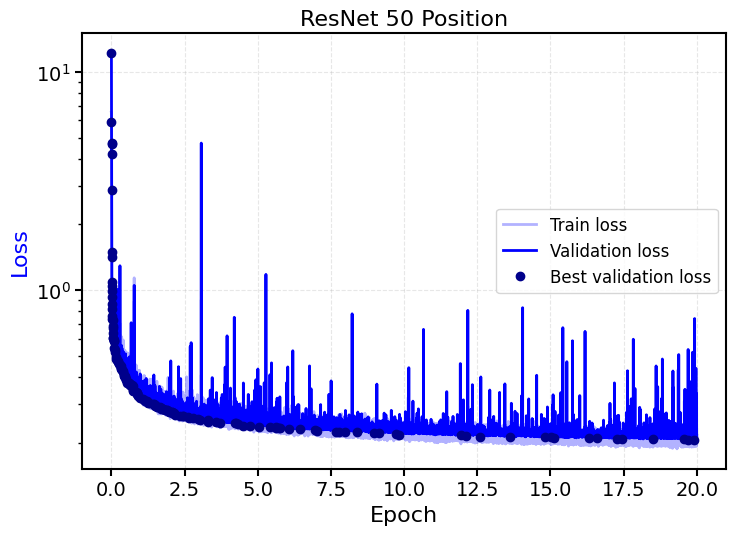

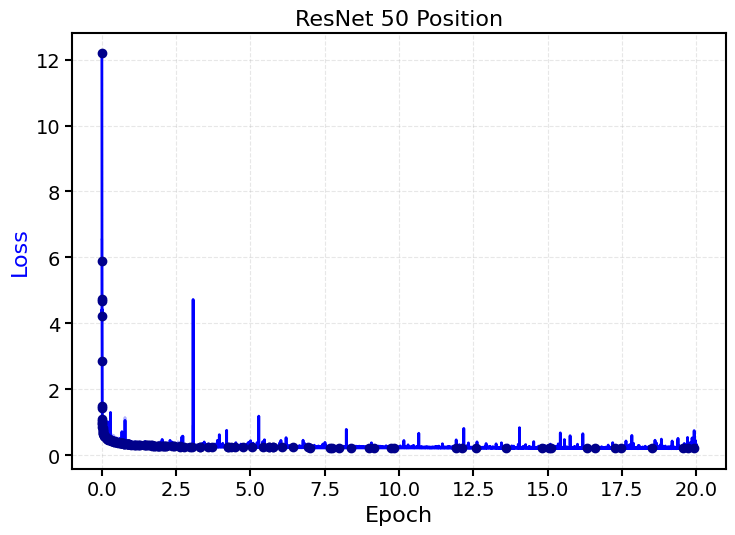

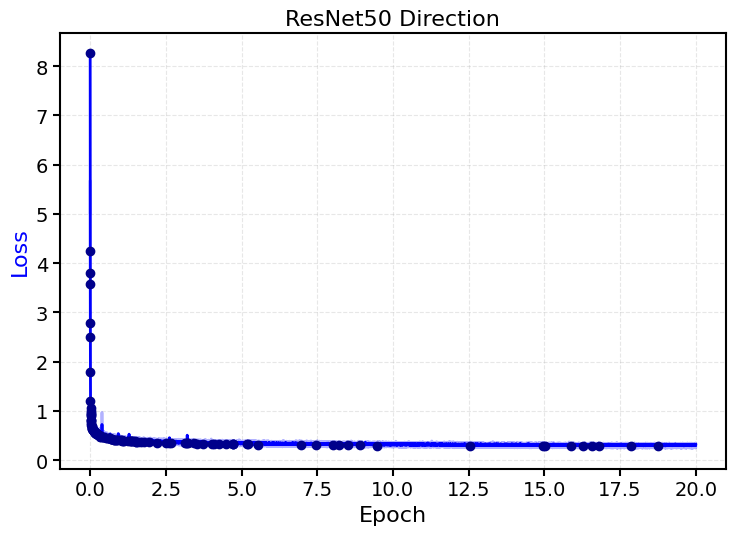

In [26]:
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
#     # ax1.set_ylim(0.1, 100)
#     # ax1.set_xlim(10,)
for r in resnet_muon_direction:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
for r in resnet_muon_position:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')
    
for r in resnet_e_position:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
for r in resnet_e_direction:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

# Energy and position statistics

In [27]:
position_stats = ['x_residuals', 'y_residuals', 'z_residuals', 'position_3d_errors', 'position_transverse_errors', 'position_longitudinal_errors', 'position_longitudinal_errors']
position_stat_labels = ["x position resolution [cm]", "y position resolution [cm]", "z position resolution [cm]", "3D position resolution [cm]", "Transverse position resolution [cm]", "Longitudinal position resolution [cm]", "Longitudinal position mean bias [cm]"]
position_stat_types = ['resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'mean']
tabulate_statistics(resnet_muon_position, position_stats, position_stat_labels, position_stat_types)

,ResNet 50 Position
x position resolution [cm],2.67
y position resolution [cm],2.72
z position resolution [cm],2.70
3D position resolution [cm],5.17
Transverse position resolution [cm],4.43
Longitudinal position resolution [cm],2.23
Longitudinal position mean bias [cm],-0.12


In [28]:
tabulate_statistics(resnet_e_position, position_stats, position_stat_labels, position_stat_types)

,ResNet 50 Position
x position resolution [cm],2.78
y position resolution [cm],2.80
z position resolution [cm],2.81
3D position resolution [cm],5.34
Transverse position resolution [cm],3.77
Longitudinal position resolution [cm],3.37
Longitudinal position mean bias [cm],-0.06


In [29]:
# energy_stats = ["momentum_fractional_errors", "momentum_residuals"]
# energy_stat_labels = ["Momentum fractional error resolution", "Momentum residual resolution"]
# energy_stat_types = ['resolution', 'resolution']

energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100

energy_stats = ["energy_residuals", 'momentum_residuals', "energy_residuals", 'momentum_residuals', energy_percentage_errors, momentum_percentage_errors,energy_percentage_errors, momentum_percentage_errors]
# energy_stats = ["energy_fractional_errors", "energy_residuals", 'momentum_residuals', 'momentum_fractional_errors']
energy_stat_labels = ["energy_residuals", 'momentum_residuals', "energy_residuals", 'momentum_residuals', 'energy_percentage_errors', 'momentum_percentage_errors','energy_percentage_errors', 'momentum_percentage_errors']
energy_stat_types = ['resolution', 'resolution', 'mean','mean', 'resolution', 'resolution','mean','mean']

tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)

# # for r in all_runs_mom:
# #     x = np.asarray(r.get_quantity("momentum_fractional_errors"))
# #     sel = r.selection
# #     if sel is not None:
# #         x = x[sel]
# #     n_total = x.size
# #     n_bad = np.sum(~np.isfinite(x))
# #     print(f"{r.run_label}: non-finite = {n_bad}/{n_total} ({(n_bad/n_total):.3%})")

# # import numpy as np

# r = resnet_muon_energy[0] # if it's a list; otherwise r = resnet_muon_energy

# # 1) Check raw predictions array
# pred = np.asarray(r.predictions)
# print("pred shape:", pred.shape)
# print("pred non-finite:", np.sum(~np.isfinite(pred)), "/", pred.size)

# # 2) Check the quantity you were testing (energy error)
# q = np.asarray(r.get_quantity("energy_residuals"))  # or the exact quantity name you're using
# sel = r.selection
# if sel is not None:
#     q = q[sel]
# print("energy_errors non-finite:", np.sum(~np.isfinite(q)), "/", q.size)

# import numpy as np

# r = resnet_muon_energy[0]  # adjust if not list

# sel = r.selection
# pred_p = np.asarray(r.momentum_prediction)  # or r.momentum_prediction attribute name
# pred_E = np.asarray(r.energy_prediction)

# t_p = np.asarray(r.true_momenta)
# t_E = np.asarray(r.true_energies)

# if sel is not None:
#     pred_p = pred_p[sel]; pred_E = pred_E[sel]
#     t_p = t_p[sel]; t_E = t_E[sel]

# print("pred momentum nonfinite:", np.sum(~np.isfinite(pred_p)))
# print("pred energy nonfinite:",   np.sum(~np.isfinite(pred_E)))
# print("true momentum nonfinite:", np.sum(~np.isfinite(t_p)))
# print("true energy nonfinite:",   np.sum(~np.isfinite(t_E)))

# mr = np.asarray(r.momentum_residuals)
# er = np.asarray(r.energy_residuals)
# if sel is not None:
#     mr = mr[sel]; er = er[sel]
# print("mom residual nonfinite:", np.sum(~np.isfinite(mr)))
# print("E residual nonfinite:",   np.sum(~np.isfinite(er)))

# Epred = np.asarray(resnet_muon_energy[0].predictions)
# print("min predicted energy:", Epred.min())
# print("fraction below muon mass:", np.mean(Epred < 105.7))

# r = resnet_muon_energy[0]
# Epred = np.asarray(r.predictions)
# Ttrue = np.asarray(r.true_momenta)  # not kinetic energy; just for comparison you need true_energies
# Etrue = np.asarray(r.true_energies)

# print("pred min:", Epred.min())
# print("fraction pred < m_mu:", np.mean(Epred < 105.7))
# print("true energy min:", Etrue.min(), "should be >= 105.7 if it's total energy")

# def summarize_energy(r, name):
#     E = np.asarray(r.predictions)
#     sel = r.selection
#     if sel is not None:
#         E = E[sel]
#     print(name,
#           "min", E.min(),
#           "p1", np.quantile(E, 0.01),
#           "p50", np.quantile(E, 0.5),
#           "frac<E_mu", np.mean(E < 105.7))

# summarize_energy(resnet_muon_energy[0], "emu")

# import numpy as np

# def finite_wrapper(run):
#     original_get_quantity = run.get_quantity

#     def get_quantity_finite(name):
#         x = np.asarray(original_get_quantity(name))
#         sel = getattr(run, "selection", None)
#         if sel is not None:
#             x = x[sel]
#         return x[np.isfinite(x)]   # <-- only change: filter here

#     run.get_quantity = get_quantity_finite
#     return run

# # apply wrapper (no change to tabulate_statistics)
# runs_filtered = [finite_wrapper(r) for r in resnet_muon_energy]

# tabulate_statistics(
#     runs_filtered,
#     energy_stats,
#     energy_stat_labels,
#     energy_stat_types
# )

,ResNet50 Energy
energy_residuals,nan
momentum_residuals,nan
energy_residuals,nan
momentum_residuals,nan
energy_percentage_errors,nan
momentum_percentage_errors,nan
energy_percentage_errors,nan
momentum_percentage_errors,nan


In [30]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

,ResNet50 Energy
energy_residuals,26.60
momentum_residuals,26.60
energy_residuals,-7.14
momentum_residuals,-7.14
energy_percentage_errors,9.74
momentum_percentage_errors,9.75
energy_percentage_errors,7.24
momentum_percentage_errors,7.27


In [31]:

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_muon_direction, dir_stats, dir_stat_labels, dir_stat_types)

,ResNet50 Direction
Direction residual error,2.18


In [32]:

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_e_direction, dir_stats, dir_stat_labels, dir_stat_types)

,ResNet50 Direction
Direction residual error,3.28


# Energy and position plots

In [33]:
# print(len(data_new_geo["positions"][h5_keep_idx][mu_mask_h5]))
# print(len(mu_pos[mu_cuts]))

# # A = test_idxs_new_geo[h5_keep_idx][mu_mask_h5]
# # B = test_idxs_new_geo[mu_idxs_new_geo][mu_cuts]

# # print(len(A), len(B))
# # print(np.array_equal(A, B))                 # identical set + order
# # print(np.array_equal(np.sort(A), np.sort(B)))  # identical set ignoring order


In [34]:
from matplotlib.ticker import MaxNLocator, LogLocator
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx] 


# instead of using the filtered muons list (from get quantities), im using all and then applying both the muon and the physical cuts as a selection filter (when binning) - therefore the baseline dimension is just the common events between h5 and fitqun

# resnet_muon_position = WatChMaLPositionRegression(
#     outdir_reg + output_pos,
#     "ResNet50 QT+mPMT_pos",
#     true_positions=data_new_geo["positions"][h5_keep_idx],
#     true_directions=data_new_geo["directions"][h5_keep_idx],
#     indices=test_idxs_new_geo[h5_keep_idx],
#     selection=mu_mask_h5
# )


resnet_muon_direction = WatChMaLPositionRegression(
    outdir_reg + output_dir,
    "ResNet50 QT+mPMT_pos",
    true_positions=data_new_geo["positions"][h5_keep_idx],
    true_directions=data_new_geo["directions"][h5_keep_idx],
    indices=test_idxs_new_geo[h5_keep_idx],
    selection=mu_mask_h5
)

fitqun_mu = FitQun1ParticleFit(
    fq,
    "fiTQun",
    true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
    true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
    true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
    true_labels=2,                        
    indices=fq_keep_idx[mu_mask_h5],       
    selection=None,
)


muon_mom_binning = [
    get_binning(data_new_geo["momentum"][h5_keep_idx], 20, 0, 1000),
    get_binning(data_new_geo["momentum"][h5_keep_idx][mu_mask_h5], 20, 0, 1000),
]

muon_cos_zenith_binning = [
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0]), 20, -1, 1),
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0][mu_mask_h5]), 20, -1, 1),
]

muon_azimuth_binning = [
    get_binning(data_new_geo["angles"][h5_keep_idx, 1] * 180 / np.pi, 20, -180, 180),
    get_binning(data_new_geo["angles"][h5_keep_idx, 1][mu_mask_h5] * 180 / np.pi, 20, -180, 180),
]

muon_dwall_binning = [
    get_binning(data_new_geo["dwall"][h5_keep_idx], 22, 50, 300),
    get_binning(data_new_geo["dwall"][h5_keep_idx][mu_mask_h5], 22, 50, 300),
]

muon_towall_binning = [
    get_binning(data_new_geo["towall"][h5_keep_idx], 30, 50, 800),
    get_binning(data_new_geo["towall"][h5_keep_idx][mu_mask_h5], 30, 50, 800),
]
all_runs_pos = [resnet_muon_direction, fitqun_mu]

for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)


# fig1, ax1 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_towall_binning[r],       
#         ax=ax1,
#         x_label="Distance to detector wall [cm]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax1.set_title("Muon 3D Position Resolution vs Distance to Wall", fontsize=16)
# fig1.tight_layout()

# handles, labels = ax1.get_legend_handles_labels()


# fig2, ax2 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_dwall_binning[r],
#         ax=ax2,
#         x_label="Distance from detector wall [cm]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax2.set_title("Muon 3D Position Resolution vs Distance from Wall", fontsize=16)
# fig2.tight_layout()

# handles, labels = ax2.get_legend_handles_labels()

# fig3, ax3 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_cos_zenith_binning[r],
#         ax=ax3,
#         x_label="Cosine of Zenith",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax3.set_title("Muon 3D Position Resolution vs Cosine of Zenith", fontsize=16)
# fig3.tight_layout()

# handles, labels = ax3.get_legend_handles_labels()


# fig4, ax4 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_azimuth_binning[r],
#         ax=ax4,
#         x_label="Azimuth [°]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax4.set_title("Muon 3D Position Resolution vs Azimuth", fontsize=16)
# fig4.tight_layout()

# handles, labels = ax4.get_legend_handles_labels()


# fig5, ax5 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_mom_binning[r],
#         ax=ax5,
#         x_label="True muon momentum [MeV]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax5.set_title("Muon 3D Position Resolution vs Momentum", fontsize=16)
# fig5.tight_layout()

# handles, labels = ax5.get_legend_handles_labels()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# fig_legend.tight_layout()

# plt.show()


NameError: name 'h5_keep_idx' is not defined

In [ ]:

# labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# # mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
# # mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx]

# resnet_muon_energy = WatChMaLEnergyRegression(
#     outdir_reg + output_energy,             
#     "ResNet50 QT+mPMT_E",
#     true_momenta=data_new_geo["momentum"][h5_keep_idx],   
#     true_labels=labels,                                  
#     indices=test_idxs_new_geo[h5_keep_idx],
#     selection=mu_mask_h5
# )

# # fitqun_mu = FitQun1ParticleFit(
# #     fq,
# #     "fiTQun",
# #     true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
# #     true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
# #     true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
# #     true_labels=2,
# #     indices=fq_keep_idx[mu_mask_h5],
# #     selection=None,
# # )

# all_runs_pos = [resnet_muon_energy, fitqun_mu]

# fig1, ax1 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_towall_binning[r],
#         ax=ax1,
#         x_label="Distance to detector wall [cm]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax1.set_title("Muon Energy Resolution vs Distance to Wall", fontsize=16)
# fig1.tight_layout()
# handles, labels = ax1.get_legend_handles_labels()

# fig2, ax2 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_dwall_binning[r],
#         ax=ax2,
#         x_label="Distance from detector wall [cm]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax2.set_title("Muon Energy Resolution vs Distance from Wall", fontsize=16)
# fig2.tight_layout()
# handles, labels = ax2.get_legend_handles_labels()

# fig3, ax3 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_cos_zenith_binning[r],
#         ax=ax3,
#         x_label="Cosine of Zenith",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax3.set_title("Muon Energy Resolution vs Cosine of Zenith", fontsize=16)
# fig3.tight_layout()
# handles, labels = ax3.get_legend_handles_labels()

# fig4, ax4 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_azimuth_binning[r],
#         ax=ax4,
#         x_label="Azimuth [°]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax4.set_title("Muon Energy Resolution vs Azimuth", fontsize=16)
# fig4.tight_layout()
# handles, labels = ax4.get_legend_handles_labels()

# fig5, ax5 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_mom_binning[r],
#         ax=ax5,
#         x_label="True muon energy [MeV]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax5.set_title("Muon Energy Resolution vs Energy", fontsize=16)
# fig5.tight_layout()
# handles, labels = ax5.get_legend_handles_labels()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# fig_legend.tight_layout()

# plt.show()